In [106]:
import pandas as pd

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print("Train Shape:",train.shape)
print("Test Shape:",test.shape)
print(train.columns[-1])

Train Shape: (1460, 81)
Test Shape: (1459, 80)
SalePrice


In [107]:
train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [108]:
train['SalePrice'].skew()

np.float64(1.8828757597682129)

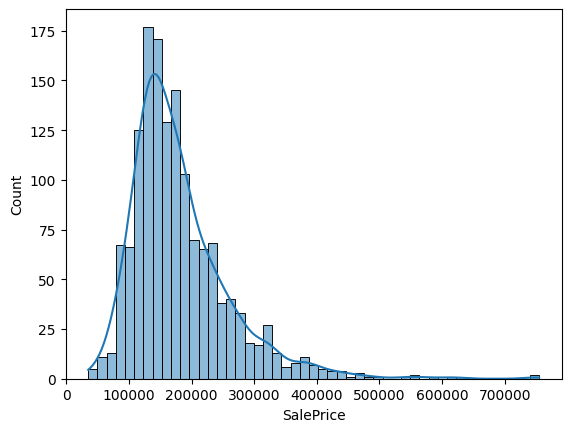

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(train['SalePrice'],kde=True)
plt.show()

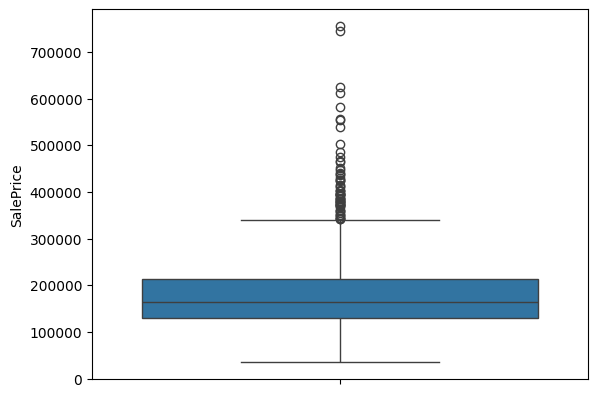

In [110]:
sns.boxplot(train['SalePrice'])
plt.show()

0.12134661989685333


<Axes: xlabel='SalePrice_log', ylabel='Count'>

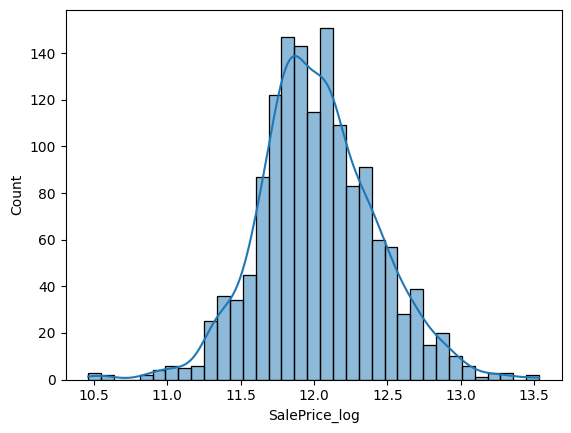

In [111]:
import numpy as np

train['SalePrice_log'] = np.log1p(train['SalePrice'])
print(train['SalePrice_log'].skew())

sns.histplot(train['SalePrice_log'],kde=True)

In [112]:
#Handling Missing Value
missing = train.isnull().sum()
missing = missing[missing>0].sort_values(ascending=True)
print(missing)

Electrical         1
MasVnrArea         8
BsmtCond          37
BsmtFinType1      37
BsmtQual          37
BsmtExposure      38
BsmtFinType2      38
GarageType        81
GarageQual        81
GarageFinish      81
GarageCond        81
GarageYrBlt       81
LotFrontage      259
FireplaceQu      690
MasVnrType       872
Fence           1179
Alley           1369
MiscFeature     1406
PoolQC          1453
dtype: int64


In [113]:
train[['Electrical','LotFrontage']].isnull().sum()

Electrical       1
LotFrontage    259
dtype: int64

In [114]:
train['Electrical'].value_counts()

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64

In [115]:
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

train['Electrical'].isnull().sum()

np.int64(0)

In [116]:
train['LotFrontage'].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

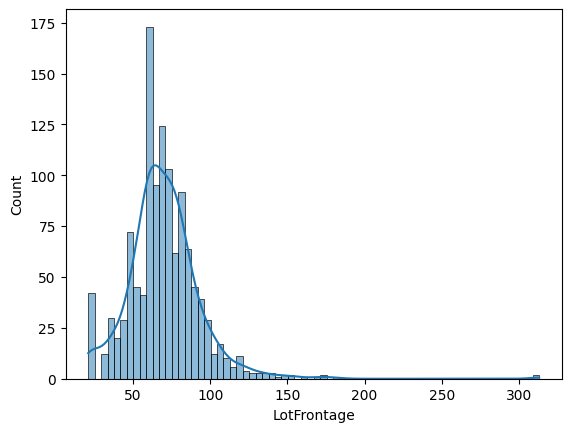

In [117]:
sns.histplot(train["LotFrontage"], kde=True)
plt.show()

In [118]:
print(train['LotFrontage'].skew())

2.163569142324884


In [119]:
train['LotFrontage'] = train.groupby('Neighborhood')[
    'LotFrontage'].transform(
        lambda x: x.fillna(
            x.median()
        )
    )

train['LotFrontage'].isnull().sum()

np.int64(0)

In [120]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtFinType1      37
BsmtQual          37
MasVnrArea         8
dtype: int64


In [121]:
none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "MasVnrType"
]

train[none_cols] = train[none_cols].fillna("None")

In [122]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

GarageYrBlt    81
MasVnrArea      8
dtype: int64


In [123]:
train["GarageYrBlt"] = train["GarageYrBlt"].fillna(0)
train["MasVnrArea"] = train["MasVnrArea"].fillna(0)

train.isnull().sum().sum()

np.int64(0)

In [124]:
tracat_cols = train.select_dtypes(include=['object']).columns
print(len(cat_cols))

30


C:\Users\user\AppData\Local\Temp\ipykernel_10032\2203659967.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  tracat_cols = train.select_dtypes(include=['object']).columns


In [125]:
train[cat_cols].head()

,MSZoning,Street,Alley,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,Heating,CentralAir,Electrical,Functional,GarageType,PavedDrive,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,None,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,GasA,Y,SBrkr,Typ,Attchd,Y,None,None,WD,Normal
1,RL,Pave,None,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,...,GasA,Y,SBrkr,Typ,Attchd,Y,None,None,WD,Normal
2,RL,Pave,None,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,GasA,Y,SBrkr,Typ,Attchd,Y,None,None,WD,Normal
3,RL,Pave,None,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,...,GasA,Y,SBrkr,Typ,Detchd,Y,None,None,WD,Abnorml
4,RL,Pave,None,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,...,GasA,Y,SBrkr,Typ,Attchd,Y,None,None,WD,Normal


In [126]:
train[cat_cols].nunique().sort_values(ascending =False)

Neighborhood     25
Exterior2nd      16
Exterior1st      15
SaleType          9
Condition1        9
HouseStyle        8
RoofMatl          8
Condition2        8
BsmtFinType2      7
Functional        7
GarageType        7
BsmtFinType1      7
Heating           6
RoofStyle         6
Foundation        6
SaleCondition     6
MiscFeature       5
Electrical        5
Fence             5
BldgType          5
MSZoning          5
LotConfig         5
LandContour       4
MasVnrType        4
LandSlope         3
Alley             3
PavedDrive        3
Utilities         2
Street            2
CentralAir        2
dtype: int64

In [127]:
for col in cat_cols:
    print(f"\n{col}:")
    print(train[col].unique())


MSZoning:
<StringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH']
Length: 5, dtype: str

Street:
<StringArray>
['Pave', 'Grvl']
Length: 2, dtype: str

Alley:
<StringArray>
['None', 'Grvl', 'Pave']
Length: 3, dtype: str

LandContour:
<StringArray>
['Lvl', 'Bnk', 'Low', 'HLS']
Length: 4, dtype: str

Utilities:
<StringArray>
['AllPub', 'NoSeWa']
Length: 2, dtype: str

LotConfig:
<StringArray>
['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3']
Length: 5, dtype: str

LandSlope:
<StringArray>
['Gtl', 'Mod', 'Sev']
Length: 3, dtype: str

Neighborhood:
<StringArray>
['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',  'NWAmes',
 'OldTown', 'BrkSide',  'Sawyer', 'NridgHt',   'NAmes', 'SawyerW',  'IDOTRR',
 'MeadowV', 'Edwards',  'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill',
 'Blmngtn',  'BrDale',   'SWISU', 'Blueste']
Length: 25, dtype: str

Condition1:
<StringArray>
['Norm', 'Feedr', 'PosN', 'Artery', 'RRAe', 'RRNn', 'RRAn', 'PosA', 'RRNe']
Length: 9, dtype: str

Condition2:
<Stri

In [128]:
ordinal_candidates = [
    col for col in cat_cols
    if any(
        keyword in col
        for keyword in [
            "Qual",
            "Cond",
            "QC",
            "Finish",
            "Exposure",
            "Shape",
            "Slope"
        ]
    )
]

print(ordinal_candidates)

['LandSlope', 'Condition1', 'Condition2', 'SaleCondition']


In [129]:
for col in ordinal_candidates:
    print(f"\n{col}:")
    print(train[col].unique())


LandSlope:
<StringArray>
['Gtl', 'Mod', 'Sev']
Length: 3, dtype: str

Condition1:
<StringArray>
['Norm', 'Feedr', 'PosN', 'Artery', 'RRAe', 'RRNn', 'RRAn', 'PosA', 'RRNe']
Length: 9, dtype: str

Condition2:
<StringArray>
['Norm', 'Artery', 'RRNn', 'Feedr', 'PosN', 'PosA', 'RRAn', 'RRAe']
Length: 8, dtype: str

SaleCondition:
<StringArray>
['Normal', 'Abnorml', 'Partial', 'AdjLand', 'Alloca', 'Family']
Length: 6, dtype: str


In [130]:
#Ordinal encoding
quality_map = {
    "None":0,
    "Po":1,
    "Fa":2,
    "TA":3,
    "Gd":4,
    "Ex":5
}

quality_cols = [
    "ExterQual",
    "ExterCond",
    "KitchenQual",
    "HeatingQC",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "PoolQC"
]

for col in quality_cols:
    train[col] = train[col].map(quality_map)

train[quality_cols].head(5)

,ExterQual,ExterCond,KitchenQual,HeatingQC,FireplaceQu,GarageQual,GarageCond,BsmtQual,BsmtCond,PoolQC
0,4,3,4,5,0,3,3,4,3,0
1,3,3,3,5,3,3,3,4,3,0
2,4,3,4,5,3,3,3,4,3,0
3,3,3,4,4,4,3,3,3,4,0
4,4,3,4,5,3,3,3,4,3,0


In [131]:
garage_finish_map = {
    "None":0,
    "Unf":1,
    "RFn":2,
    "Fin":3
}

train['GarageFinish'] = train['GarageFinish'].map(garage_finish_map)

train['GarageFinish'].head(5)


0    2
1    2
2    2
3    1
4    2
Name: GarageFinish, dtype: int64

In [132]:
bsmt_exposure_map = {
    "None":0,
    "No":1,
    "Mn":2,
    "Av":3,
    "Gd":4
}

train['BsmtExposure'] = train['BsmtExposure'].map(bsmt_exposure_map)
train['BsmtExposure'].head(5)

0    1
1    4
2    2
3    1
4    3
Name: BsmtExposure, dtype: int64

In [133]:
lotshape_map = {
    "IR3":1,
    "IR2":2,
    "IR1":3,
    "Reg":4
}

train['LotShape'] = train['LotShape'].map(lotshape_map)

train['LotShape'].head(5)

0    4
1    4
2    3
3    3
4    3
Name: LotShape, dtype: int64

In [134]:
cat_cols = train.select_dtypes(include=["object"]).columns

print(len(cat_cols))
print(cat_cols)

30
Index(['MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
       'MasVnrType', 'Foundation', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'CentralAir', 'Electrical', 'Functional', 'GarageType', 'PavedDrive',
       'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'],
      dtype='str')


C:\Users\user\AppData\Local\Temp\ipykernel_10032\1646494048.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include=["object"]).columns


In [135]:
for col in ordinal_candidates:
    if train[col].dtype == "object":
        print(f"\n{col}:")
        print(train[col].unique())

In [136]:
train[ordinal_candidates].head(10)

,LandSlope,Condition1,Condition2,SaleCondition
0,Gtl,Norm,Norm,Normal
1,Gtl,Feedr,Norm,Normal
2,Gtl,Norm,Norm,Normal
3,Gtl,Norm,Norm,Abnorml
4,Gtl,Norm,Norm,Normal
5,Gtl,Norm,Norm,Normal
6,Gtl,Norm,Norm,Normal
7,Gtl,PosN,Norm,Normal
8,Gtl,Artery,Norm,Abnorml
9,Gtl,Artery,Artery,Normal


In [137]:
train[ordinal_candidates].info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   LandSlope      1460 non-null   str  
 1   Condition1     1460 non-null   str  
 2   Condition2     1460 non-null   str  
 3   SaleCondition  1460 non-null   str  
dtypes: str(4)
memory usage: 45.8 KB


In [138]:
landslope_map = {
    "Gtl":1,
    "Mod":2,
    "Sev":3
}

train["LandSlope"] = train["LandSlope"].map(
    landslope_map
)

train['LandSlope'].head(10)

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: LandSlope, dtype: int64

In [ ]:
ordinal_cols = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "GarageFinish",
    "LotShape",
    "LandSlope"
]

train[ordinal_cols].info()